# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kavanaaykavna/1stmlassignment/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## 1. Ranked Actions + Reason Codes

The ranking uses the audited Week 6 modeling approach rather than the original Week 5 random-split result.

Pages are ranked using the model's estimated probability of belonging to the observed declining-impression class, combined with practical SEO signals such as:

- page age
- days since last update
- CTR
- average position
- recent engagement

The resulting queue is intended for prioritization, not automatic action.

### Reason codes

Each page receives one or more human-readable reason codes.

Examples:

- `DECLINE_RISK` — relatively high model score for the observed declining label.
- `STALE_CONTENT` — page has not been updated recently.
- `LOW_CTR` — page has relatively low click-through rate.
- `MATURE_PAGE` — page is relatively old.
- `WEAK_POSITION` — page has a relatively poor average search position.
- `REFRESH_CANDIDATE` — multiple signals indicate that a human review may be useful.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [6]:
# Load the FlyRank dataset
df = pd.read_csv("content_refresh_anonymized.csv")
# Create the observed decline label
df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower().eq("down").astype(int)
)

print("Dataset shape:", df.shape)
print("Declining label distribution:")
print(df["is_declining_label"].value_counts())

Dataset shape: (30000, 45)
Declining label distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64


## Modeling setup

The Week 6 audit used a client-grouped split so that pages from the same client were not present in both training and test sets.

The model also removed the two 30-day impression variables because the decline label itself is constructed from the comparison between the recent and previous 30-day impression periods.

This notebook follows the same audited setup for consistency.

In [8]:
# Week 5 numeric feature set
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

# Remove variables directly involved in constructing the target
leakage_features = [
    "impressions_last_30d",
    "impressions_prev_30d"
]

honest_features = [
    f for f in features
    if f not in leakage_features
]

X = df[honest_features]
y = df["is_declining_label"]
groups = df["client_id"]

print("Number of audited features:", len(honest_features))
print("Removed leakage-prone features:", leakage_features)

Number of audited features: 27
Removed leakage-prone features: ['impressions_last_30d', 'impressions_prev_30d']


In [9]:
# Client-grouped 80/20 split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Overlapping clients:", len(train_clients.intersection(test_clients)))

Training rows: 23837
Test rows: 6163
Training clients: 25
Test clients: 7
Overlapping clients: 0


In [10]:
# Train the audited Logistic Regression model
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

# Evaluate on the honest test set
y_pred = model.predict(X_test)

honest_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred)
}

print("Week 6 / Week 7 audited model results:")
for metric, value in honest_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Week 6 / Week 7 audited model results:
accuracy: 0.5958
precision: 0.6048
recall: 0.6030
f1: 0.6039

Confusion matrix:
[[1773 1241]
 [1250 1899]]


## Creating the action queue

The model probability is used as one prioritization signal.

This is deliberately different from saying that the model "predicts" future decline with certainty.

The queue answers a narrower operational question:

> Which pages show stronger measured signals associated with the observed declining label and may deserve earlier human review?

Higher scores indicate higher review priority, not guaranteed future decline.

In [11]:
# Score every page in the dataset
df["decline_score"] = model.predict_proba(df[honest_features])[:, 1]

# Create practical signal flags
df["stale_flag"] = df["days_since_last_update"] > 180
df["mature_flag"] = df["content_age_days"] > 270
df["low_ctr_flag"] = df["ctr"] < 0.03
df["weak_position_flag"] = df["avg_position"] > 10

# Percentile-based score for easier ranking
df["priority_score"] = (
    df["decline_score"].rank(pct=True) * 100
)

print(df["priority_score"].describe())

count    30000.000000
mean        50.001667
std         28.867995
min          0.003333
25%         25.002500
50%         50.001667
75%         75.000833
max        100.000000
Name: priority_score, dtype: float64


In [12]:
def create_reason_codes(row):
    reasons = []

    if row["decline_score"] >= 0.70:
        reasons.append("DECLINE_RISK")

    if row["stale_flag"]:
        reasons.append("STALE_CONTENT")

    if row["low_ctr_flag"]:
        reasons.append("LOW_CTR")

    if row["mature_flag"]:
        reasons.append("MATURE_PAGE")

    if row["weak_position_flag"]:
        reasons.append("WEAK_POSITION")

    if len(reasons) >= 2:
        reasons.append("REFRESH_CANDIDATE")

    if not reasons:
        reasons.append("MONITOR")

    return "|".join(reasons)


df["reason_codes"] = df.apply(create_reason_codes, axis=1)

print(df["reason_codes"].value_counts().head(10))

reason_codes
LOW_CTR|MATURE_PAGE|WEAK_POSITION|REFRESH_CANDIDATE    3706
MATURE_PAGE|WEAK_POSITION|REFRESH_CANDIDATE            3369
MATURE_PAGE                                            3101
LOW_CTR                                                2917
LOW_CTR|WEAK_POSITION|REFRESH_CANDIDATE                2588
DECLINE_RISK                                           2567
DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE           2517
LOW_CTR|MATURE_PAGE|REFRESH_CANDIDATE                  2238
MONITOR                                                2097
WEAK_POSITION                                          2072
Name: count, dtype: int64


## Archetype → Action Mapping

The action should depend on the combination of observed signals rather than the model score alone.

| Archetype | Typical signals | Recommended action |
|---|---|---|
| Mature + stale | Old page and long time since update | Refresh review |
| High decline score | Stronger association with observed decline | Prioritize SEO review |
| Low CTR + reasonable position | Page receives impressions but captures fewer clicks | Title/snippet review |
| Weak position | Average position is outside page-one range | Content/search-intent review |
| Young page | Recently created content | Monitor before major changes |
| Strong/healthy signals | No major warning signals | Monitor |
| Ambiguous signals | Conflicting or incomplete evidence | Manual investigation |

These mappings are decision-support rules. They do not prescribe automatic content edits.

In [13]:
def assign_archetype(row):
    if row["mature_flag"] and row["stale_flag"]:
        return "MATURE_STALE"

    if row["low_ctr_flag"] and row["avg_position"] <= 10:
        return "LOW_CTR_PAGE_ONE"

    if row["weak_position_flag"]:
        return "WEAK_POSITION"

    if row["decline_score"] >= 0.70:
        return "HIGH_DECLINE_SCORE"

    if row["content_age_days"] < 90:
        return "YOUNG_PAGE"

    return "GENERAL_MONITOR"


df["archetype"] = df.apply(assign_archetype, axis=1)

archetype_actions = {
    "MATURE_STALE": "REFRESH_REVIEW",
    "LOW_CTR_PAGE_ONE": "CTR_OPTIMIZATION_REVIEW",
    "WEAK_POSITION": "CONTENT_AND_INTENT_REVIEW",
    "HIGH_DECLINE_SCORE": "PRIORITY_SEO_REVIEW",
    "YOUNG_PAGE": "MONITOR",
    "GENERAL_MONITOR": "MONITOR"
}

df["recommended_action"] = df["archetype"].map(archetype_actions)

print(df["archetype"].value_counts())

archetype
WEAK_POSITION         15790
LOW_CTR_PAGE_ONE       5846
GENERAL_MONITOR        5199
HIGH_DECLINE_SCORE     3058
MATURE_STALE            107
Name: count, dtype: int64


## Action priority

The queue uses the following practical priority levels:

- **P1 — High:** multiple warning signals or high observed decline score.
- **P2 — Medium:** one or more meaningful optimization signals.
- **P3 — Monitor:** insufficient evidence for immediate intervention.

Priority is a review order, not an automated decision.

In [14]:
def assign_priority(row):
    reason_count = len(row["reason_codes"].split("|"))

    if (
        row["decline_score"] >= 0.70
        and reason_count >= 2
    ):
        return "P1"

    if (
        row["decline_score"] >= 0.50
        or reason_count >= 2
    ):
        return "P2"

    return "P3"


df["priority"] = df.apply(assign_priority, axis=1)

priority_order = {
    "P1": 1,
    "P2": 2,
    "P3": 3
}

df["priority_order"] = df["priority"].map(priority_order)

action_queue = df.sort_values(
    ["priority_order", "priority_score"],
    ascending=[True, False]
).copy()

print("Priority distribution:")
print(action_queue["priority"].value_counts())

Priority distribution:
priority
P2    19892
P1     5196
P3     4912
Name: count, dtype: int64


In [15]:
# Select the fields needed by an SEO reviewer
queue_columns = [
    "content_id",
    "client_id",
    "priority",
    "priority_score",
    "decline_score",
    "archetype",
    "recommended_action",
    "reason_codes",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "word_count",
    "engagement_rate",
    "trend_direction"
]

action_queue_export = action_queue[queue_columns].copy()

action_queue_export.head(20)

,content_id,client_id,priority,priority_score,decline_score,archetype,recommended_action,reason_codes,content_age_days,days_since_last_update,ctr,avg_position,word_count,engagement_rate,trend_direction
6836,content_a965a1fc5544,client_6208ef0f77,P1,99.986667,1.000000,WEAK_POSITION,CONTENT_AND_INTENT_REVIEW,DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE,236,104,0.64,12.7,7809.0,5.40,stable
12400,content_482aff19e9cc,client_7f2253d7e2,P1,99.980000,0.999986,WEAK_POSITION,CONTENT_AND_INTENT_REVIEW,DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE,106,106,2.43,13.2,3038.0,4.82,down
2365,content_4a18c07e5357,client_4e07408562,P1,99.976667,0.999970,HIGH_DECLINE_SCORE,PRIORITY_SEO_REVIEW,DECLINE_RISK|MATURE_PAGE|REFRESH_CANDIDATE,390,104,0.86,4.5,NaN,9.53,down
26413,content_bdd7c88a58ed,client_4e07408562,P1,99.973333,0.999963,HIGH_DECLINE_SCORE,PRIORITY_SEO_REVIEW,DECLINE_RISK|MATURE_PAGE|REFRESH_CANDIDATE,421,14,0.84,3.1,3033.0,1.47,down
556,content_3a426ee4383c,client_19581e27de,P1,99.970000,0.999962,HIGH_DECLINE_SCORE,PRIORITY_SEO_REVIEW,DECLINE_RISK|MATURE_PAGE|REFRESH_CANDIDATE,362,104,0.96,3.5,NaN,1.85,down
28335,content_007d1f134801,client_4e07408562,P1,99.960000,0.999912,HIGH_DECLINE_SCORE,PRIORITY_SEO_REVIEW,DECLINE_RISK|MATURE_PAGE|REFRESH_CANDIDATE,326,25,0.90,6.4,2538.0,6.32,down
12064,content_4090f0acd977,client_4e07408562,P1,99.956667,0.999887,HIGH_DECLINE_SCORE,PRIORITY_SEO_REVIEW,DECLINE_RISK|MATURE_PAGE|REFRESH_CANDIDATE,421,25,1.05,6.5,3110.0,4.19,down
7481,content_50426bec207f,client_6208ef0f77,P1,99.953333,0.999875,WEAK_POSITION,CONTENT_AND_INTENT_REVIEW,DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE,125,104,0.71,11.5,3575.0,6.31,down
6345,content_47b8b12d581e,client_7f2253d7e2,P1,99.950000,0.999862,WEAK_POSITION,CONTENT_AND_INTENT_REVIEW,DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE,106,106,0.96,28.4,2713.0,3.43,down
21939,content_b5ce413af5ed,client_7f2253d7e2,P1,99.936667,0.999524,WEAK_POSITION,CONTENT_AND_INTENT_REVIEW,DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE,147,20,1.07,18.9,3875.0,3.36,down


## Decay / Refresh Insight

The FlyRank research paper reports an observational content-performance pattern in which performance peaks around the 61–90 day period and declines after approximately 270 days. The paper also notes that the older-page rebound is concentrated among pages that had been refreshed.

This should be interpreted as an observational pattern, not proof that refreshing a page causes performance to increase.

For the action playbook, this means mature and stale pages can be useful candidates for human review, especially when combined with other measured warning signals.

The recommended action is therefore:

**Review → diagnose → decide → refresh if justified**

rather than:

**Age → automatically refresh.**

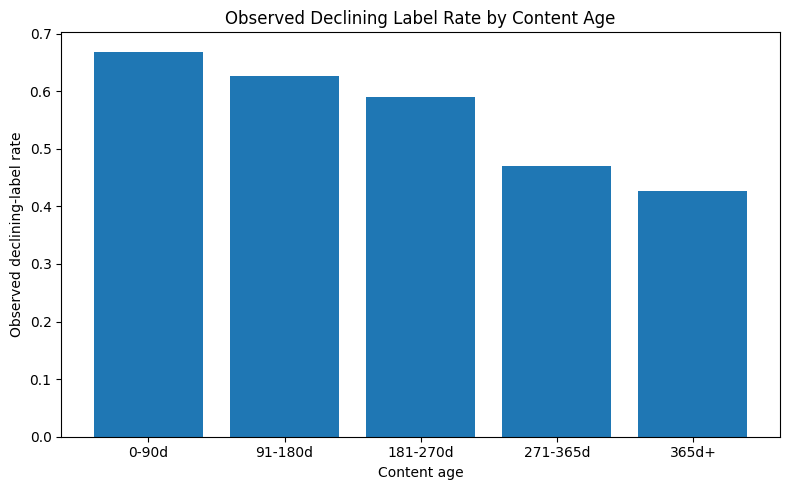

In [16]:
# Create a simple reusable decay/refresh figure
age_bins = [0, 90, 180, 270, 365, np.inf]
age_labels = [
    "0-90d",
    "91-180d",
    "181-270d",
    "271-365d",
    "365d+"
]

df["age_group"] = pd.cut(
    df["content_age_days"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_summary = (
    df.groupby("age_group", observed=False)["is_declining_label"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(
    age_summary["age_group"].astype(str),
    age_summary["is_declining_label"]
)

plt.xlabel("Content age")
plt.ylabel("Observed declining-label rate")
plt.title("Observed Declining Label Rate by Content Age")
plt.tight_layout()

os.makedirs("work/figures", exist_ok=True)
plt.savefig(
    "work/figures/content_age_decline_rate.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Cost / Value Thinking

The queue should prioritize work where the expected value of human review is reasonably high.

A practical prioritization principle is:

**Priority ≈ evidence of opportunity × potential value ÷ review cost**

Potential value may include:

- business importance of the page
- search demand
- existing traffic
- strategic importance
- conversion relevance

Review cost may include:

- complexity of the page
- amount of content required
- SME/editorial effort
- technical dependencies

The model does not estimate financial value or causal uplift. Therefore, cost/value is a human decision layer applied after the model ranking.

In [17]:
# Create a simple operational value proxy.
# This is NOT revenue or predicted business value.
# It only helps demonstrate how a team could prioritize review effort.

search_volume_norm = (
    df["search_volume"]
    .fillna(0)
    .rank(pct=True)
)

priority_value_proxy = (
    0.6 * df["priority_score"] +
    40 * search_volume_norm
)

df["review_value_proxy"] = priority_value_proxy

# Combine model priority with search demand as a review-ranking aid
df["final_review_score"] = (
    0.7 * df["priority_score"] +
    30 * search_volume_norm
)

action_queue = df.sort_values(
    "final_review_score",
    ascending=False
).copy()

print(
    action_queue[
        [
            "content_id",
            "priority",
            "archetype",
            "recommended_action",
            "reason_codes",
            "final_review_score"
        ]
    ].head(10)
)

                 content_id priority           archetype  \
27762  content_79d64a8d8c8c       P2  HIGH_DECLINE_SCORE   
4354   content_510a85d01661       P2  HIGH_DECLINE_SCORE   
28371  content_6e098546a7a2       P2  HIGH_DECLINE_SCORE   
10039  content_fd21cc3cb506       P1  HIGH_DECLINE_SCORE   
14190  content_11fcfd65d94c       P2  HIGH_DECLINE_SCORE   
10843  content_b0dd771d5f36       P2  HIGH_DECLINE_SCORE   
26099  content_9f3faa01b66c       P1  HIGH_DECLINE_SCORE   
11577  content_20e876d26019       P1       WEAK_POSITION   
5926   content_bc437c20d7ed       P2  HIGH_DECLINE_SCORE   
24734  content_46c9510685ef       P1       WEAK_POSITION   

              recommended_action  \
27762        PRIORITY_SEO_REVIEW   
4354         PRIORITY_SEO_REVIEW   
28371        PRIORITY_SEO_REVIEW   
10039        PRIORITY_SEO_REVIEW   
14190        PRIORITY_SEO_REVIEW   
10843        PRIORITY_SEO_REVIEW   
26099        PRIORITY_SEO_REVIEW   
11577  CONTENT_AND_INTENT_REVIEW   
5926         PR

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## 2. Intended Use and Limits

### Intended use

This playbook is intended to help SEO teams:

1. identify pages that deserve earlier review;
2. understand the measured signals behind the ranking;
3. organize pages into practical content archetypes;
4. decide where human investigation may have the highest value;
5. monitor the model and dataset for changes.

### Limits

The model should not be interpreted as proof that a page will decline in the future.

The validation audit showed that performance was lower under a client-grouped split than under the original random split. This means the original random-split result should not be treated as a guaranteed estimate of performance on unseen clients.

The dataset is also a snapshot rather than a complete production forecasting history.

Several performance variables are measured over overlapping time windows with the decline label. Although the two direct 30-day variables were removed, the remaining 90-day variables can still overlap temporally with the label construction.

Therefore the model is best treated as:

**directional decision-support for SEO prioritization, with human review.**

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## 3. Human Review + No-Go List

Every P1 and P2 recommendation requires human review before any content change.

### Human reviewer checklist

Before changing a page, review:

- current search intent
- target keyword/topic
- SERP competition
- current rankings
- current CTR
- traffic and conversion importance
- content quality
- factual accuracy
- internal links
- backlinks and authority
- recent algorithm or SERP changes
- whether the page has already been refreshed
- whether the observed decline may be temporary

### What should NOT be automated

The system should not automatically:

- publish content;
- rewrite or delete pages;
- change search intent;
- change canonical URLs;
- remove pages;
- redirect URLs;
- change metadata without review;
- make claims about causality;
- declare a page permanently "bad";
- make financial or business-impact claims from the score alone.

The model provides prioritization evidence. A human makes the final content decision.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## 4. Monitoring / Retrain Triggers

The model should be monitored before being considered for repeated operational use.

### Monitoring signals

Monitor:

- class/label distribution
- score distribution
- precision and recall on newly labeled data
- false-positive and false-negative rates
- performance by client
- performance by content age group
- performance by content type/archetype
- missing-value rates
- feature distributions

### Potential retrain triggers

A retraining review should be considered when:

1. the observed label distribution changes substantially;
2. new clients or content types become common;
3. feature distributions shift materially;
4. validation F1 declines meaningfully;
5. precision or recall falls below an agreed business threshold;
6. the relationship between age, freshness and performance changes;
7. the data collection or label definition changes.

These are monitoring/review triggers rather than automatic retraining rules.

In [18]:
# Basic monitoring statistics for the current dataset

monitoring_summary = {
    "dataset_rows": int(len(df)),
    "declining_label_rate": float(df["is_declining_label"].mean()),
    "mean_decline_score": float(df["decline_score"].mean()),
    "median_decline_score": float(df["decline_score"].median()),
    "missing_rate_days_since_update": float(
        df["days_since_last_update"].isna().mean()
    ),
    "missing_rate_ctr": float(
        df["ctr"].isna().mean()
    ),
    "missing_rate_avg_position": float(
        df["avg_position"].isna().mean()
    )
}

monitoring_summary

{'dataset_rows': 30000,
 'declining_label_rate': 0.5420666666666667,
 'mean_decline_score': 0.5399555408026285,
 'median_decline_score': 0.5543897130530502,
 'missing_rate_days_since_update': 0.0,
 'missing_rate_ctr': 0.0,
 'missing_rate_avg_position': 0.0}

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## 5. Exports for the Paper

The ranked queue is exported to `work/outputs/`.

The queue is intentionally not treated as a source-controlled dataset. The notebook regenerates it from the source data.

Metrics and figures are retained as reproducible evidence for the research paper.

In [19]:
# Create output directories
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Final queue columns
final_queue_columns = [
    "content_id",
    "client_id",
    "priority",
    "final_review_score",
    "priority_score",
    "decline_score",
    "archetype",
    "recommended_action",
    "reason_codes",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "word_count",
    "search_volume",
    "engagement_rate"
]

final_queue = action_queue[final_queue_columns].copy()

# Export queue
queue_path = "work/outputs/action_queue.csv"
final_queue.to_csv(queue_path, index=False)

print(f"Exported ranked queue to: {queue_path}")
print("Rows exported:", len(final_queue))

Exported ranked queue to: work/outputs/action_queue.csv
Rows exported: 30000


In [20]:
# Export model metrics / validation receipts

metrics_export = {
    "validation_method": "client_grouped_80_20_split",
    "random_state": 42,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "train_clients": int(len(train_clients)),
    "test_clients": int(len(test_clients)),
    "overlapping_clients": int(
        len(train_clients.intersection(test_clients))
    ),
    "removed_leakage_features": leakage_features,
    "num_honest_features": len(honest_features),
    "metrics": {
        key: round(float(value), 4)
        for key, value in honest_metrics.items()
    }
}

metrics_path = "work/outputs/w07_validation_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics_export, f, indent=2)

print(f"Exported metrics to: {metrics_path}")

Exported metrics to: work/outputs/w07_validation_metrics.json


In [21]:
# Export monitoring summary

monitoring_path = "work/outputs/w07_monitoring_summary.json"

with open(monitoring_path, "w") as f:
    json.dump(monitoring_summary, f, indent=2)

print(f"Exported monitoring summary to: {monitoring_path}")

print("\nFiles created:")
print("-", queue_path)
print("-", metrics_path)
print("-", monitoring_path)
print("-", "work/figures/content_age_decline_rate.png")

Exported monitoring summary to: work/outputs/w07_monitoring_summary.json

Files created:
- work/outputs/action_queue.csv
- work/outputs/w07_validation_metrics.json
- work/outputs/w07_monitoring_summary.json
- work/figures/content_age_decline_rate.png


## Paper-ready summary

### Recommended playbook

The model output should be used as a ranked review queue rather than an automated content decision system.

High-priority pages are those with stronger measured association with the observed declining label and/or multiple practical SEO warning signals.

The main action categories are:

- **Refresh review** for mature and stale pages.
- **CTR optimization review** for pages with relatively low CTR despite reasonable position.
- **Content and intent review** for pages with weaker search positions.
- **Priority SEO review** for pages with stronger decline scores.
- **Monitor** where evidence is insufficient for immediate intervention.

The research paper's decay/refresh finding supports using mature and stale pages as review candidates, but the evidence is observational and does not establish that refreshing a page causes improved performance.

All recommendations require human review.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 6. Self-Check

### Methodology
- [x] Used the audited client-grouped validation approach.
- [x] Removed the two 30-day impression features directly involved in label construction.
- [x] Confirmed that training and test clients do not overlap.

### Action playbook
- [x] Created a ranked action queue.
- [x] Added reason codes.
- [x] Added archetype → action mapping.
- [x] Included decay/refresh insight.
- [x] Included practical cost/value thinking.

### Responsible use
- [x] Clearly stated intended use.
- [x] Documented limitations.
- [x] Added human-review rules.
- [x] Added a no-go automation list.
- [x] Added monitoring and retraining triggers.
- [x] Avoided causal or guaranteed-performance claims.

### Exports
- [x] Exported `action_queue.csv`.
- [x] Exported validation metrics JSON.
- [x] Exported monitoring summary JSON.
- [x] Saved a reusable figure under `work/figures/`.

The playbook is intended as non-production, human-reviewed decision-support.